# LSTM Sürüş Profili Analizi
Bu notebook, OBD verilerini yükleyerek LSTM modeli için ön işleme adımlarını gerçekleştirir.

## 1. Kütüphaneler

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Veri Yükleme

In [45]:
CSV_PATH = 'data/2017-07-28_Seat_Leon_KA_RT_Stau.csv'

df = pd.read_csv(
    CSV_PATH,
    encoding='latin-1',
    parse_dates=['Time'],
    date_format='%H:%M:%S.%f'
)

df.columns = [
    'Time',
    'Coolant_Temp',
    'Intake_MAP',
    'Engine_RPM',
    'Vehicle_Speed',
    'Intake_Air_Temp',
    'MAF',
    'Throttle_Pos',
    'Ambient_Temp',
    'Accel_Pedal_D',
    'Accel_Pedal_E'
]

print(f'Toplam satır sayısı : {len(df):,}')
print(f'Toplam sütun sayısı : {len(df.columns)}')
df.head(10)

Toplam satır sayısı : 73,200
Toplam sütun sayısı : 11


,Time,Coolant_Temp,Intake_MAP,Engine_RPM,Vehicle_Speed,Intake_Air_Temp,MAF,Throttle_Pos,Ambient_Temp,Accel_Pedal_D,Accel_Pedal_E
0,1900-01-01 17:35:01.602,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1900-01-01 17:35:01.652,33,99.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1900-01-01 17:35:01.741,33,99.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1900-01-01 17:35:01.831,33,99.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
4,1900-01-01 17:35:01.921,33,99.00,0.00,0.00,23.00,NaN,NaN,NaN,NaN,NaN
5,1900-01-01 17:35:02.012,33,99.00,0.00,0.00,23.00,0.91,NaN,NaN,NaN,NaN
6,1900-01-01 17:35:02.102,33,99.00,0.00,0.00,23.00,0.91,89.00,NaN,NaN,NaN
7,1900-01-01 17:35:02.194,33,99.00,0.00,0.00,23.00,0.91,89.00,22.00,NaN,NaN
8,1900-01-01 17:35:02.254,33,99.00,0.00,0.00,23.00,0.91,89.00,22.00,14.10,NaN
9,1900-01-01 17:35:02.342,33,99.00,0.00,0.00,23.00,0.91,89.00,22.00,14.10,14.50


## 3. Genel Bilgi ve Veri Tipleri

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73200 entries, 0 to 73199
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Time             73200 non-null  datetime64[ns]
 1   Coolant_Temp     73200 non-null  int64         
 2   Intake_MAP       73199 non-null  float64       
 3   Engine_RPM       73198 non-null  float64       
 4   Vehicle_Speed    73197 non-null  float64       
 5   Intake_Air_Temp  73196 non-null  float64       
 6   MAF              73195 non-null  float64       
 7   Throttle_Pos     73194 non-null  float64       
 8   Ambient_Temp     73193 non-null  float64       
 9   Accel_Pedal_D    73192 non-null  float64       
 10  Accel_Pedal_E    73191 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 6.1 MB


## 4. İstatistiksel Özet

In [47]:
df.describe()

,Time,Coolant_Temp,Intake_MAP,Engine_RPM,Vehicle_Speed,Intake_Air_Temp,MAF,Throttle_Pos,Ambient_Temp,Accel_Pedal_D,Accel_Pedal_E
count,73200,73200.00,73199.00,73198.00,73197.00,73196.00,73195.00,73194.00,73193.00,73192.00,73191.00
mean,1900-01-01 18:30:09.998663680,86.54,125.52,1439.22,59.01,35.92,22.02,82.92,23.34,22.23,22.55
min,1900-01-01 17:35:01.602000,31.00,36.00,0.00,0.00,-8.00,0.00,13.70,22.00,14.10,14.10
25%,1900-01-01 18:04:28.568499968,90.00,103.00,972.25,16.00,28.00,9.44,83.50,23.00,14.10,14.50
50%,1900-01-01 18:30:40.351000064,91.00,114.00,1520.00,48.00,30.00,17.97,83.50,23.00,14.10,14.50
75%,1900-01-01 18:57:18.566499840,93.00,137.00,1878.00,104.00,38.00,29.02,83.50,24.00,27.80,27.80
max,1900-01-01 19:23:13.532000,101.00,232.00,3111.00,184.00,150.00,107.16,89.00,25.00,78.00,77.30
std,NaN,14.61,32.01,615.40,48.23,19.56,17.38,7.25,0.65,13.14,13.18


## 5. Eksik Değer Analizi

                 Eksik Sayısı  Eksik Oranı (%)
Time                        0             0.00
Coolant_Temp                0             0.00
Intake_MAP                  1             0.00
Engine_RPM                  2             0.00
Vehicle_Speed               3             0.00
Intake_Air_Temp             4             0.01
MAF                         5             0.01
Throttle_Pos                6             0.01
Ambient_Temp                7             0.01
Accel_Pedal_D               8             0.01
Accel_Pedal_E               9             0.01


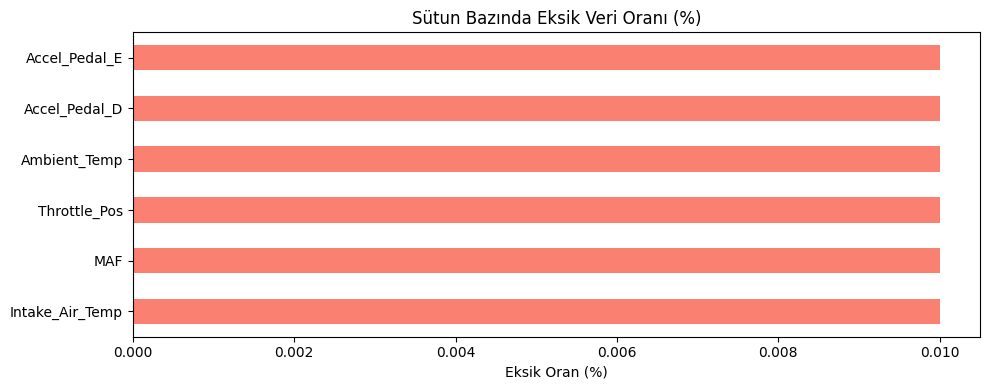

In [48]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Eksik Sayısı': missing,
    'Eksik Oranı (%)': missing_pct
})

print(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', ax=ax, color='salmon')
ax.set_title('Sütun Bazında Eksik Veri Oranı (%)')
ax.set_xlabel('Eksik Oran (%)')
plt.tight_layout()
plt.show()

## 6. Zaman Sütununun Düzenlenmesi

In [49]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S.%f', errors='coerce')
df['Elapsed_s'] = (df['Time'] - df['Time'].iloc[0]).dt.total_seconds()

print(f"Kayıt süresi: {df['Elapsed_s'].max():.1f} saniye ({df['Elapsed_s'].max()/60:.1f} dakika)")
df[['Time', 'Elapsed_s']].head()

Kayıt süresi: 6491.9 saniye (108.2 dakika)


,Time,Elapsed_s
0,1900-01-01 17:35:01.602,0.00
1,1900-01-01 17:35:01.652,0.05
2,1900-01-01 17:35:01.741,0.14
3,1900-01-01 17:35:01.831,0.23
4,1900-01-01 17:35:01.921,0.32


## 7. Temel Sinyallerin Görselleştirilmesi

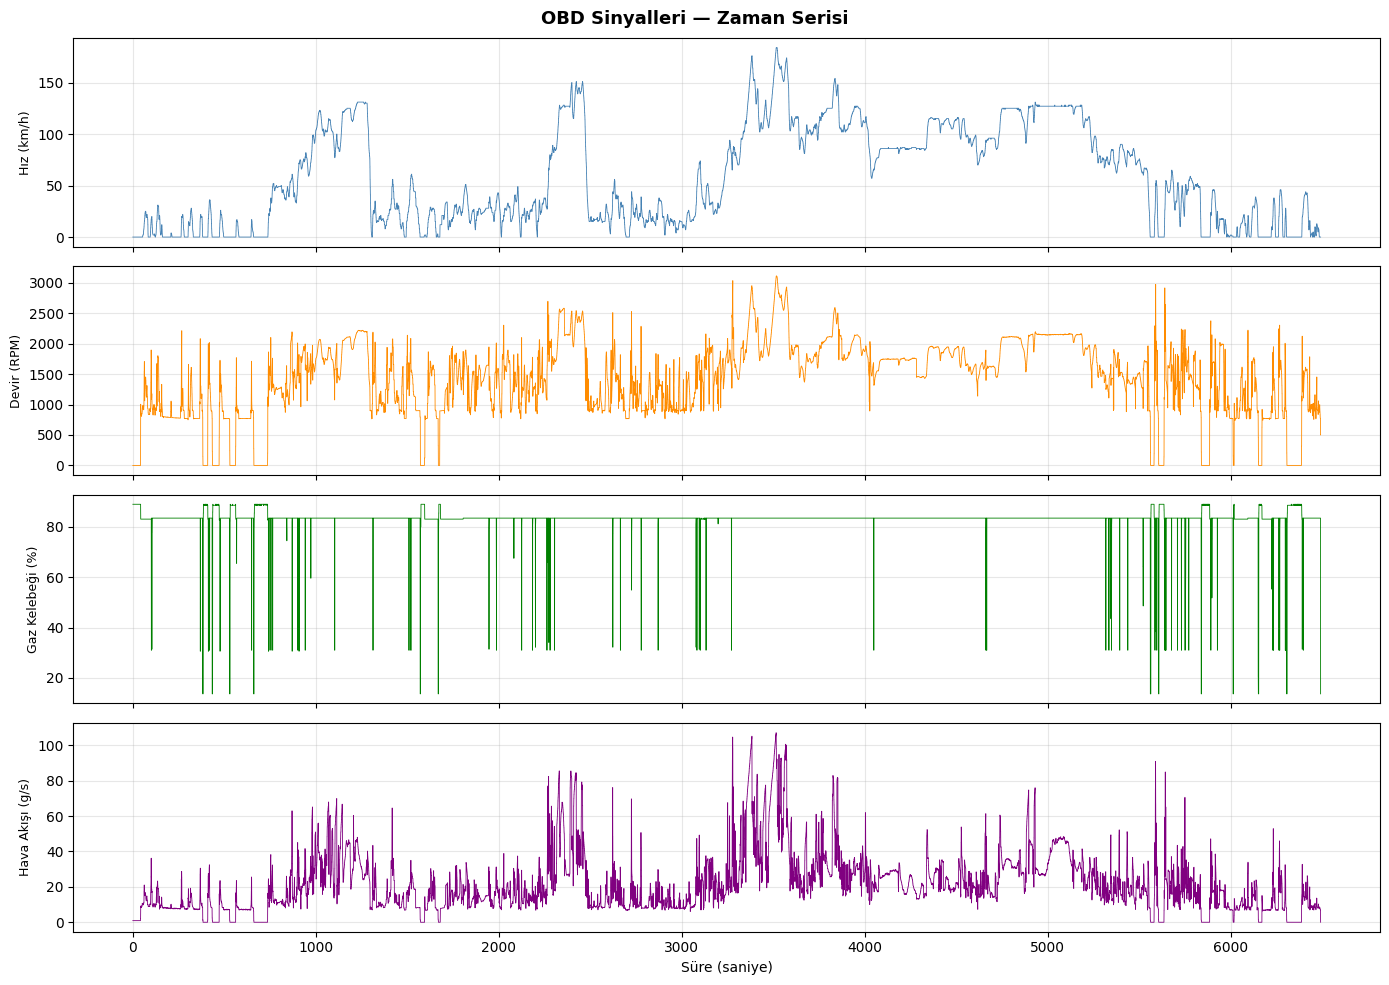

In [50]:
signals = [
    ('Vehicle_Speed', 'Hız (km/h)', 'steelblue'),
    ('Engine_RPM',    'Devir (RPM)', 'darkorange'),
    ('Throttle_Pos',  'Gaz Kelebeği (%)', 'green'),
    ('MAF',           'Hava Akışı (g/s)', 'purple'),
]

fig, axes = plt.subplots(len(signals), 1, figsize=(14, 10), sharex=True)

for ax, (col, label, color) in zip(axes, signals):
    ax.plot(df['Elapsed_s'], df[col], linewidth=0.6, color=color)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Süre (saniye)')
fig.suptitle('OBD Sinyalleri — Zaman Serisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Saniye Bazında Yeniden Örnekleme (Resample)

OBD her PID'i sırayla sorguladığı için aynı saniyede birden fazla satır oluşur.
LSTM için **eşit aralıklı (1 Hz)** bir zaman serisi gerektiğinden:
- Aynı saniyedeki tüm ölçümler **ortalanır**
- Eksik saniyeler **doğrusal interpolasyon** ile doldurulur (max 5 ardışık boş saniye)
- Çıkış `df_1s`: tamamen ardışık, 1 satır = 1 saniye

In [51]:
# Time sütununu index yap ve resample uygula
analysis_start_time = pd.to_datetime('17:42:53', format='%H:%M:%S').time()

df_1s = (
    df.set_index('Time')
      .drop(columns=['Elapsed_s'])          # eski süre sütununu at
      .resample('1s')                        # her saniyeye bir satır
      .mean(numeric_only=True)               # aynı saniyedeki satırları ortala
      .interpolate(method='linear', limit=5) # boş saniyeleri doldur (max 5 ardışık)
      .reset_index()
)

rows_before_filter = len(df_1s)

# Araç çalışmadan önceki bölüm analiz dışında bırakılır.
df_1s = df_1s[df_1s['Time'].dt.time >= analysis_start_time].copy()
df_1s.reset_index(drop=True, inplace=True)

# Başlangıçtan itibaren geçen saniyeyi, filtrelenmiş verinin ilk satırından başlat.
df_1s['Elapsed_s'] = (df_1s['Time'] - df_1s['Time'].iloc[0]).dt.total_seconds().astype(int)

# Görüntüleme için yıl-ay-gün bilgisini kaldır.
df_1s['Time'] = df_1s['Time'].dt.strftime('%H:%M:%S')

print(f'Ham satır sayısı           : {len(df):,}')
print(f'Resample sonrası           : {rows_before_filter:,} saniye')
print(f'Filtre sonrası             : {len(df_1s):,} saniye')
print(f'Kullanılmayan ilk bölüm    : {rows_before_filter - len(df_1s):,} saniye')
print(f'Analiz başlangıç zamanı    : {analysis_start_time}')
print(f'Kalan NaN sayısı           : {df_1s.isnull().sum().sum()}')
df_1s.head(15)

Ham satır sayısı           : 73,200
Resample sonrası           : 6,493 saniye
Filtre sonrası             : 6,021 saniye
Kullanılmayan ilk bölüm    : 472 saniye
Analiz başlangıç zamanı    : 17:42:53
Kalan NaN sayısı           : 0


,Time,Coolant_Temp,Intake_MAP,Engine_RPM,Vehicle_Speed,Intake_Air_Temp,MAF,Throttle_Pos,Ambient_Temp,Accel_Pedal_D,Accel_Pedal_E,Elapsed_s
0,17:42:53,58.00,165.00,269.50,0.00,77.75,5.35,87.12,24.00,14.79,14.50,0
1,17:42:54,58.00,116.18,875.82,0.00,63.45,13.40,82.85,24.00,22.53,22.70,1
2,17:42:55,58.00,101.00,982.67,3.00,41.00,10.38,83.10,24.00,23.10,22.80,2
3,17:42:56,58.00,105.25,1111.00,8.92,26.67,12.99,83.10,24.00,28.60,28.18,3
4,17:42:57,58.00,116.50,1562.67,13.75,19.50,21.63,83.10,24.00,37.50,37.57,4
5,17:42:58,58.00,111.73,1488.27,16.36,15.64,22.25,35.41,24.00,30.53,34.62,5
6,17:42:59,58.00,108.69,1202.38,19.15,10.15,17.07,83.50,24.00,39.37,39.83,6
7,17:43:00,58.00,122.09,1360.73,23.18,6.73,18.25,83.50,24.00,37.99,38.78,7
8,17:43:01,58.00,122.00,1489.33,25.56,4.67,16.68,83.50,24.00,29.34,31.21,8
9,17:43:02,58.00,113.82,1410.18,24.55,2.73,14.12,83.50,24.00,15.82,15.94,9


## 9. Model İçin Özellik Seçimi

Sürüş profili tahmini için doğrudan davranışı temsil eden sütunlar kullanılacak. Sıcaklık sütunları, zaman sütunları ve `Accel_Pedal_D` ile neredeyse aynı bilgiyi taşıyan `Accel_Pedal_E` model girdisinden çıkarılır.

In [ ]:
feature_cols = [
    'Engine_RPM',
    'Vehicle_Speed',
    'Intake_MAP',
    'MAF',
    'Throttle_Pos',
    'Accel_Pedal_D'
]

unused_cols = [
    'Time',
    'Elapsed_s',
    'Coolant_Temp',
    'Intake_Air_Temp',
    'Ambient_Temp',
    'Accel_Pedal_E'
]

# df_1s zaman ve kontrol bilgilerini korur; df_model sadece LSTM girdisi olacak özellikleri içerir.
df_model = df_1s[feature_cols].copy()

print('Modelde kullanılacak sütunlar:')
print(feature_cols)

print('\nModel dışında bırakılan sütunlar:')
print(unused_cols)

print(f'\ndf_1s boyutu   : {df_1s.shape}')
print(f'df_model boyutu: {df_model.shape}')
print(f'Toplam NaN     : {df_model.isnull().sum().sum()}')

df_model.head(10)

Modelde kullanılacak sütunlar:
['Engine_RPM', 'Vehicle_Speed', 'Intake_MAP', 'MAF', 'Throttle_Pos', 'Accel_Pedal_D']

Model dışında bırakılan sütunlar:
['Time', 'Elapsed_s', 'Coolant_Temp', 'Intake_Air_Temp', 'Ambient_Temp', 'Accel_Pedal_E']

df_1s boyutu   : (6021, 12)
df_model boyutu: (6021, 6)
Toplam NaN     : 0


,Engine_RPM,Vehicle_Speed,Intake_MAP,MAF,Throttle_Pos,Accel_Pedal_D
0,269.50,0.00,165.00,5.35,87.12,14.79
1,875.82,0.00,116.18,13.40,82.85,22.53
2,982.67,3.00,101.00,10.38,83.10,23.10
3,1111.00,8.92,105.25,12.99,83.10,28.60
4,1562.67,13.75,116.50,21.63,83.10,37.50
5,1488.27,16.36,111.73,22.25,35.41,30.53
6,1202.38,19.15,108.69,17.07,83.50,39.37
7,1360.73,23.18,122.09,18.25,83.50,37.99
8,1489.33,25.56,122.00,16.68,83.50,29.34
9,1410.18,24.55,113.82,14.12,83.50,15.82


## 10. Resample Sonrası Eksik Değer Kontrolü

In [53]:
remaining_nan = df_1s.isnull().sum()
remaining_nan = remaining_nan[remaining_nan > 0]

if remaining_nan.empty:
    print('Tüm sütunlar tam dolu — NaN yok.')
else:
    print('Hâlâ NaN içeren sütunlar:')
    print(remaining_nan)
    print('\nBu sütunlar 5 saniyeden uzun kesintiler içeriyor.')
    print('Seçenek 1: forward-fill  →  df_1s.ffill(inplace=True)')
    print('Seçenek 2: sütunu analiz dışı bırak')

Tüm sütunlar tam dolu — NaN yok.


## 11. Resample Sonrası Sinyal Karşılaştırması

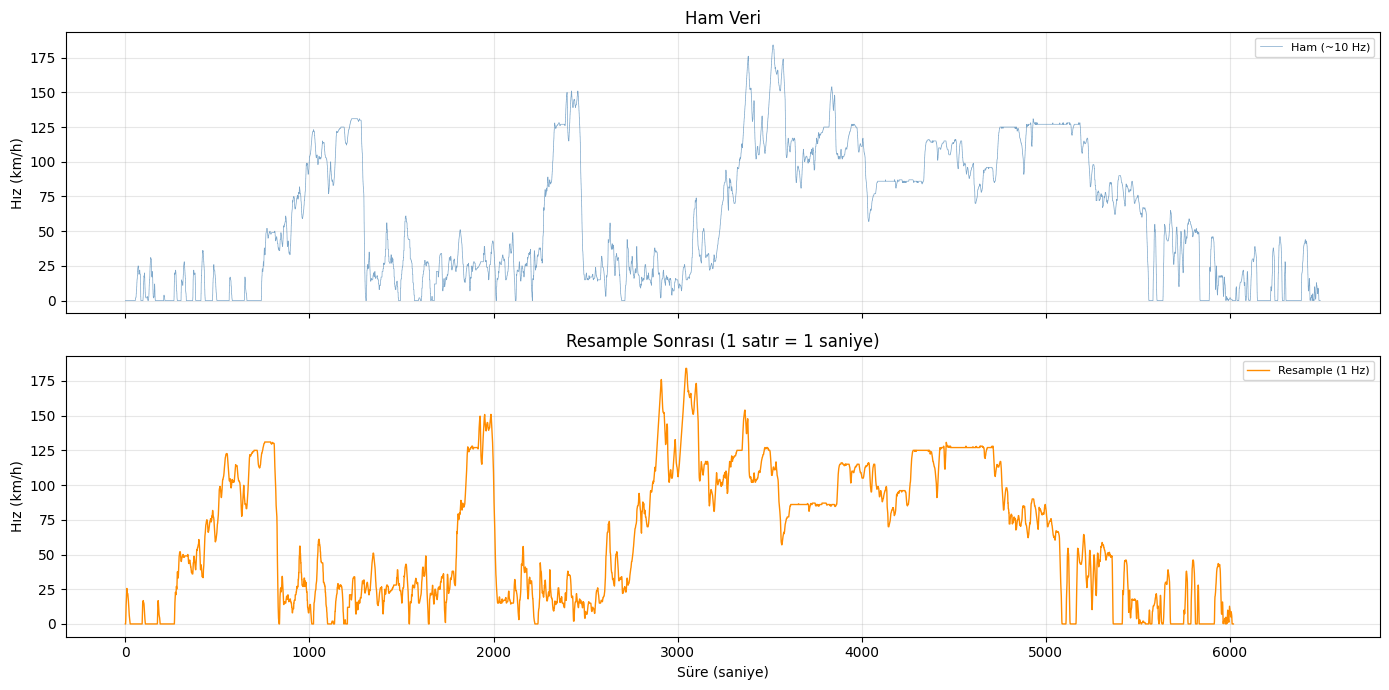

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Ham veri
axes[0].plot(df['Elapsed_s'], df['Vehicle_Speed'],
             linewidth=0.5, color='steelblue', alpha=0.7, label='Ham (~10 Hz)')
axes[0].set_ylabel('Hız (km/h)')
axes[0].set_title('Ham Veri')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Resample edilmiş veri
axes[1].plot(df_1s['Elapsed_s'], df_1s['Vehicle_Speed'],
             linewidth=1.0, color='darkorange', label='Resample (1 Hz)')
axes[1].set_ylabel('Hız (km/h)')
axes[1].set_xlabel('Süre (saniye)')
axes[1].set_title('Resample Sonrası (1 satır = 1 saniye)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# İstenen hassasiyette düzenleme
int_cols = ['Engine_RPM', 'Vehicle_Speed']
one_decimal_cols = ['Intake_MAP', 'Throttle_Pos', 'Accel_Pedal_D']
two_decimal_cols = ['MAF']

df_model[int_cols] = df_model[int_cols].round(0).astype(int)
df_model[one_decimal_cols] = df_model[one_decimal_cols].round(1)
df_model[two_decimal_cols] = df_model[two_decimal_cols].round(2)

print('\ndf_model veri tipleri:')
print(df_model.dtypes)



df_model veri tipleri:
Engine_RPM         int32
Vehicle_Speed      int32
Intake_MAP       float64
MAF              float64
Throttle_Pos     float64
Accel_Pedal_D    float64
dtype: object
